# Stellar Classification and Supervised Learning
This notebook demonstrates how to build, train, and evaluate multiple models (both traditional ML and PyTorch Neural Networks) using our custom `stellar_classification` package.

In [1]:
import sys
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [2]:
# Load dataset
data_path = '/home/sara/lcpB/Computational-Physics-2026/Astrophysical-Objects-Recognition/stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# Color indexes 
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

star.info()

First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

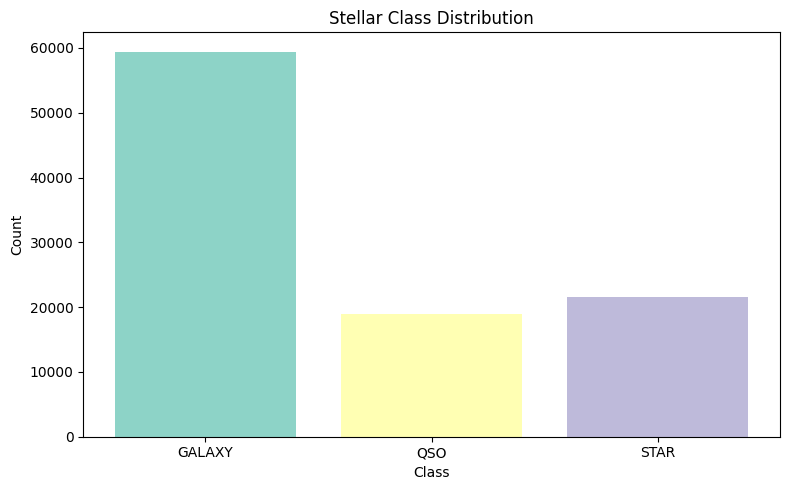

In [3]:
# Visualize Class Distribution
sc.plot_class_distribution(star['class'], title="Stellar Class Distribution")


In [4]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)


In [5]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")


DataLoaders created.


In [6]:
# dataframe completo con target
X_full = pd.DataFrame(X_test, columns=feature_names)
X_full["class"] = label_encoder.inverse_transform(y_test)

# feature colore
color_features = ["u_g", "g_r", "r_i", "i_z"]

# media dei colori per classe
color_table = X_full.groupby("class")[color_features].mean()

print(color_table)

             u_g       g_r       r_i       i_z
class                                         
GALAXY  0.213888  0.492081  0.453777  0.369712
QSO    -0.807408 -1.013359 -0.863616 -0.505106
STAR    0.114865 -0.504203 -0.510716 -0.542782


In [7]:
# Train and evaluate traditional ML models
#models = sc.train_traditional(X_train, y_train, X_val, y_val)

In [8]:
# Train Voting Classifier utilizing the trained models
#voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)
#y_test_pred_voting = voting_clf.predict(X_test)
#voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")

In [9]:
# Confusion Matrices
#class_names = list(label_encoder.classes_)
#sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier')

In [10]:
# Feature Importance (using permutation importance on the Voting Classifier)
#imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names)
#sc.plot_permutation_importance(imp, top_n=10)

#print("Feature Importance Scores:")
#for feat, val in imp.items():
 #   print(f"{feat}: {val:.4f}")


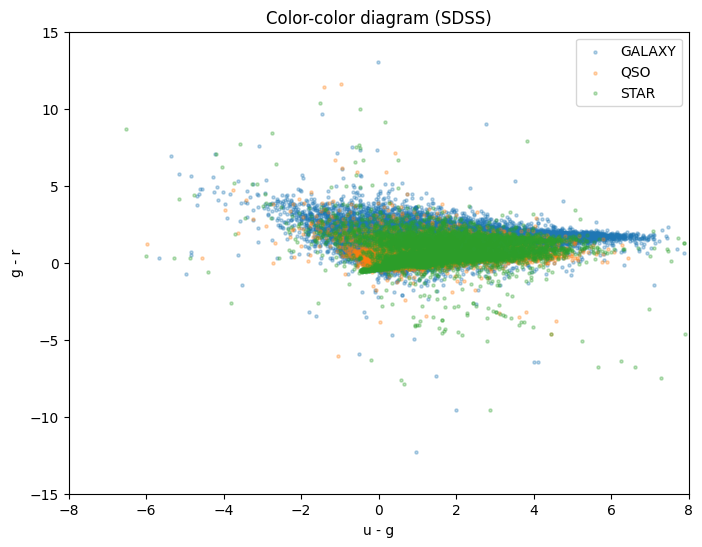

In [11]:
star = pd.read_csv(data_path)

# pulizia minima (fondamentale)
star = star.dropna(subset=['u','g','r','class'])

# indici di colore
star['u_g'] = star['u'] - star['g']
star['g_r'] = star['g'] - star['r']

plt.figure(figsize=(8,6))

for c in star['class'].unique():
    subset = star[star['class'] == c]
    plt.scatter(subset['u_g'], subset['g_r'],
                label=c,
                s=5,
                alpha=0.3)
    plt.xlim(-8, 8)
    plt.ylim(-15, 15)

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.legend()
plt.title('Color-color diagram (SDSS)')
plt.show()

## XGBoost

In [12]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_jobs=3)

params = {"n_estimators": [300,500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10],
}

best_model_xgb, best_params_xgb, best_score_xgb = sc.tune_model(
    xgb,
    params,
    X_train,
    y_train,
)

print("Best Hyperparameters:", best_params_xgb)

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [13]:
best_params_xgb.pop("n_estimators", None)
best_params_xgb.pop("max_depth", None)

xgb_final = XGBClassifier(**best_params_xgb,n_estimators=1000,max_depth=3, objective="multi:softprob",
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=42)
xgb_final.fit(X_train, y_train,eval_set=[(X_val, y_val)],verbose=False)

train_metrics_xgb, val_metrics_xgb = sc.evaluate_single_model(
    xgb_final,
    X_train, y_train,
    X_val, y_val,
    model_name="XGBoost Tuned"
)

y_test_pred_xgb = xgb_final.predict(X_test)
xgb_metrics = sc.evaluate_test_set(y_test, y_test_pred_xgb, "XGBoost")
sc.print_metrics(xgb_metrics)
X_test_df = pd.DataFrame(X_test, columns=feature_names)


[Training] Acc=91.3462% P=0.9136 R=0.9135 F1=0.9133
Confusion Matrix:
[[30560   929   855]
 [ 1602 29191  1551]
 [ 1268  2192 28884]]

[Validation] Acc=90.2120% P=0.8713 R=0.8797 F1=0.8749
Confusion Matrix:
[[10122   368   291]
 [  213  3088   247]
 [  268   400  3260]]


XGBoost:
  Accuracy  : 90.41%
  Precision: 0.8731
  Recall   : 0.8823
  F1       : 0.8773
  Confusion Matrix:
[[10129   366   286]
 [  219  3073   256]
 [  239   385  3304]]


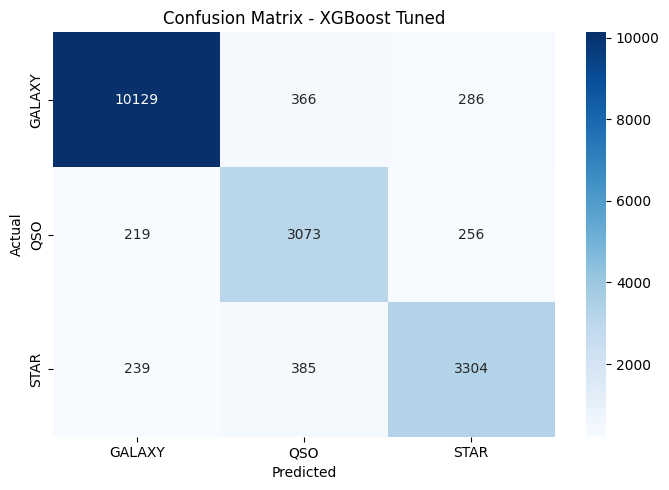

In [ ]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(xgb_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - XGBoost Tuned')


SHAP summary for class: GALAXY


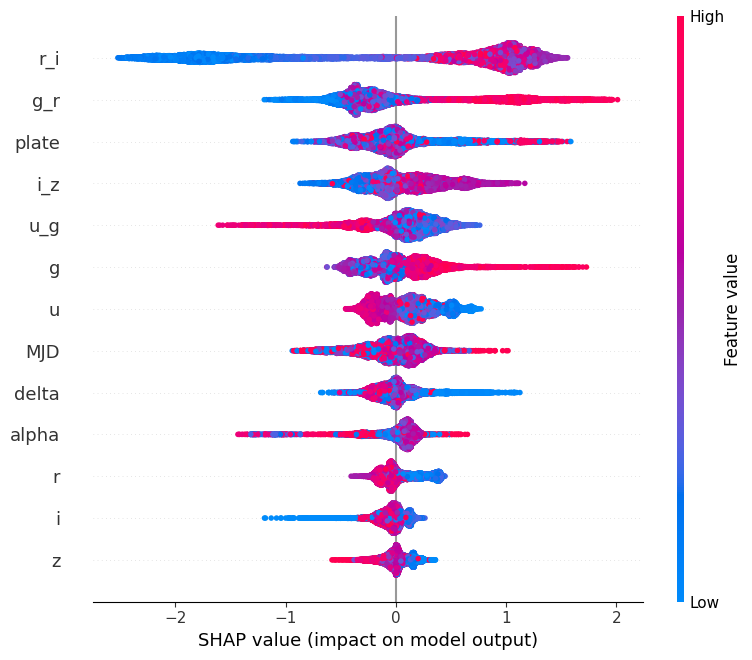


SHAP summary for class: QSO


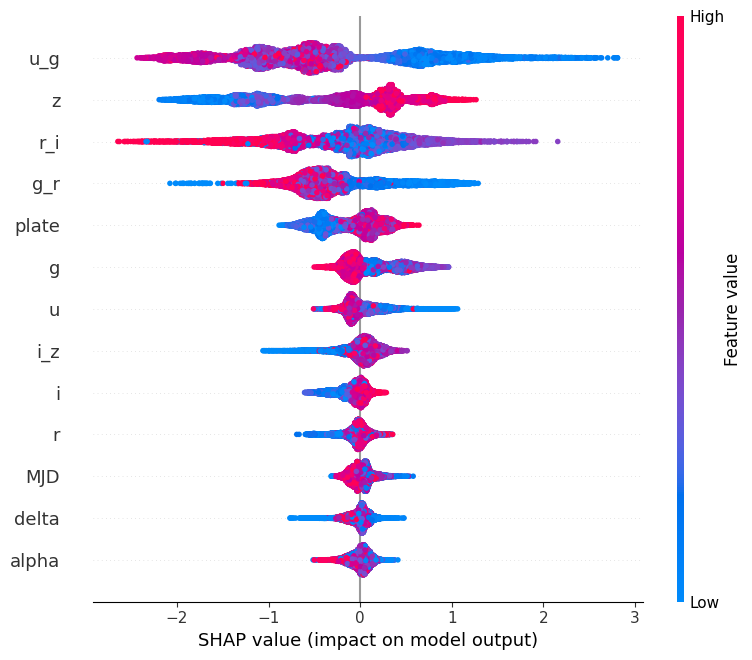


SHAP summary for class: STAR


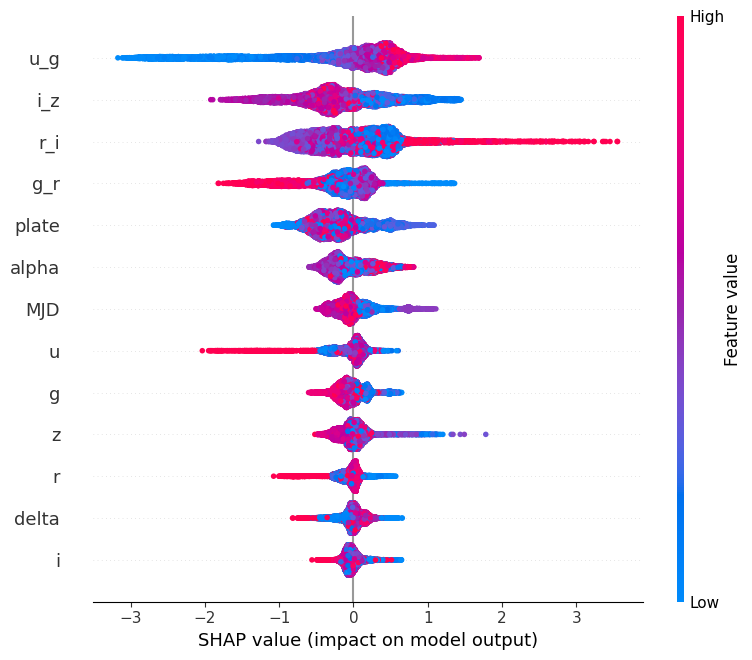

In [ ]:
shap_values_xgb = sc.shap_summary_tree_model(
    model=xgb_final,
    X=X_test,
    feature_names=feature_names,
    class_names=label_encoder.classes_
)

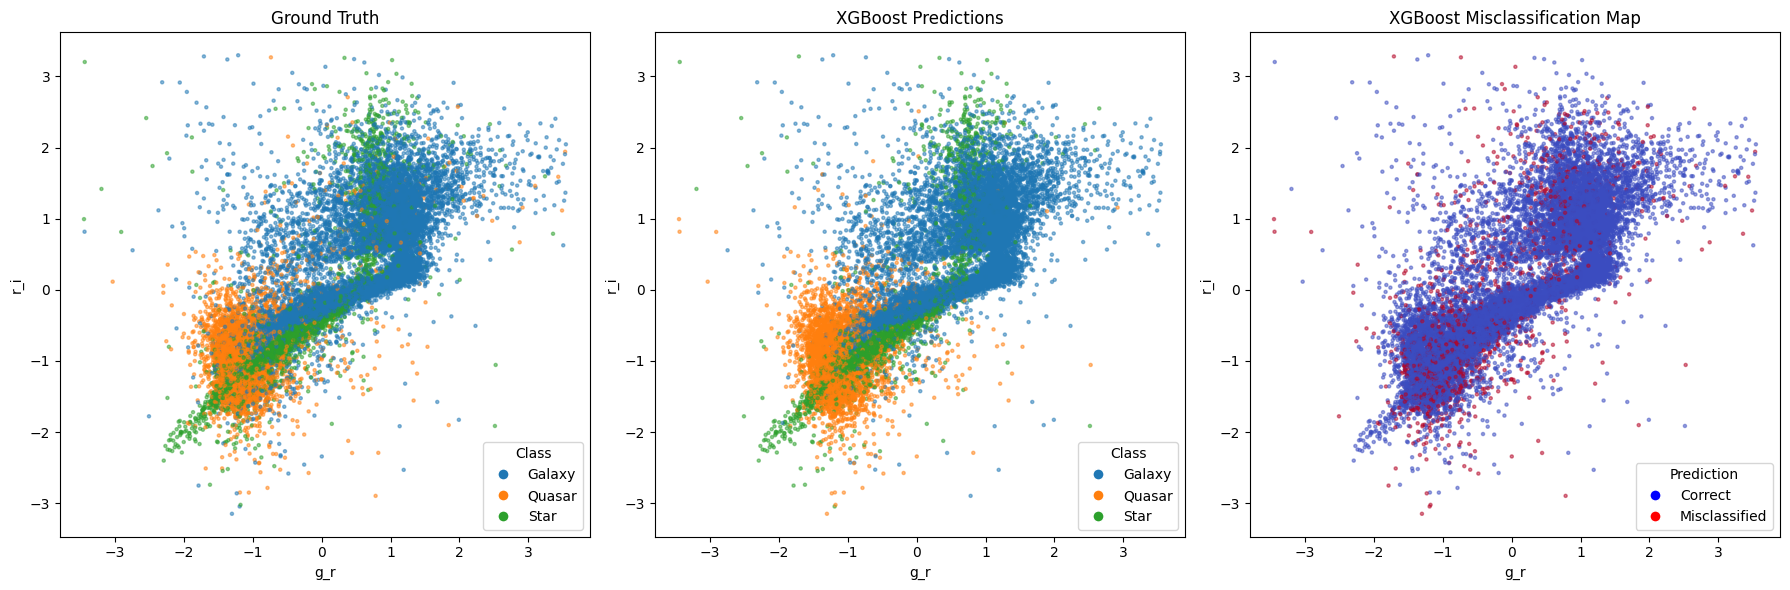

In [14]:
sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="XGBoost"
)
#aggiungere legenda

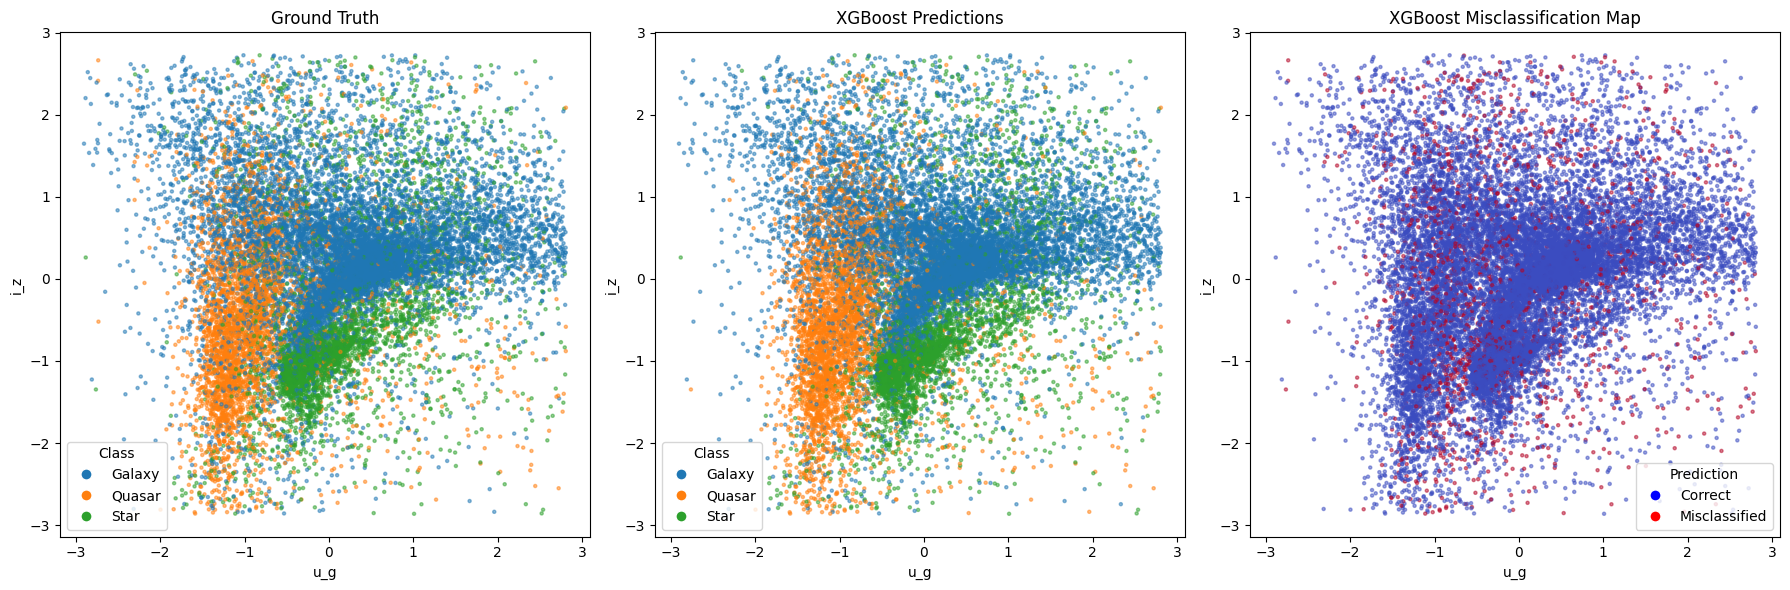

In [15]:
sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    feature_x="u_g",
    feature_y="i_z",
    title_prefix="XGBoost")

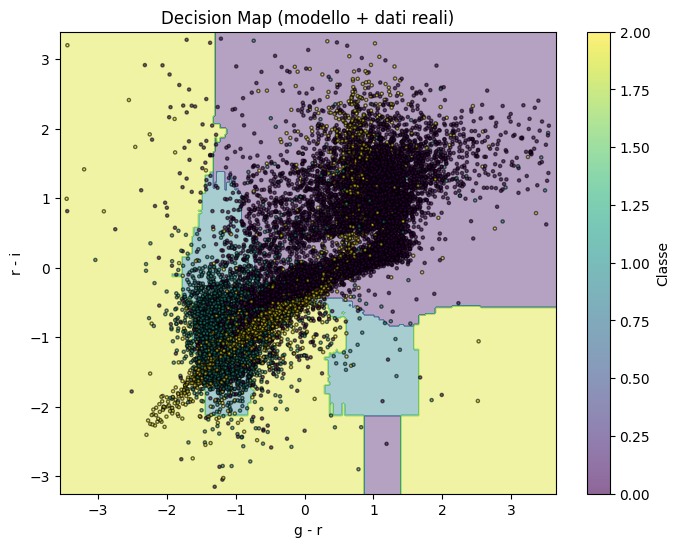

In [16]:
X = X_test_df.copy()   
y = y_test        

# 2. SCELTA PIANO 2D
x_feat = "g_r"
y_feat = "r_i"

x_min, x_max = X[x_feat].min() - 0.1, X[x_feat].max() + 0.1
y_min, y_max = X[y_feat].min() - 0.1, X[y_feat].max() + 0.1

# 3. GRIGLIA
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]


# 4. INPUT MODELLO COMPLETO
# ordine delle feature usate nel modello
feature_names = X.columns

X_dummy = pd.DataFrame(
    np.zeros((grid.shape[0], len(feature_names))),
    columns=feature_names
)

# inserisci le 2 feature del piano
X_dummy[x_feat] = grid[:, 0]
X_dummy[y_feat] = grid[:, 1]

# riempi le altre con la media (approssimazione standard)
for col in feature_names:
    if col not in [x_feat, y_feat]:
        X_dummy[col] = X[col].mean()


# 5. PREDIZIONE
Z = xgb_final.predict(X_dummy)
Z = Z.reshape(xx.shape)

# 6. PLOT
plt.figure(figsize=(8,6))

# decision boundary del modello
plt.contourf(xx, yy, Z, alpha=0.4, cmap="viridis")

# punti reali
plt.scatter( X[x_feat], X[y_feat],  c=y, s=5, cmap="viridis", edgecolor="k", alpha=0.6)

plt.xlabel("g - r")
plt.ylabel("r - i")
plt.title("Decision Map (modello + dati reali)")
plt.colorbar(label="Classe")
plt.show()

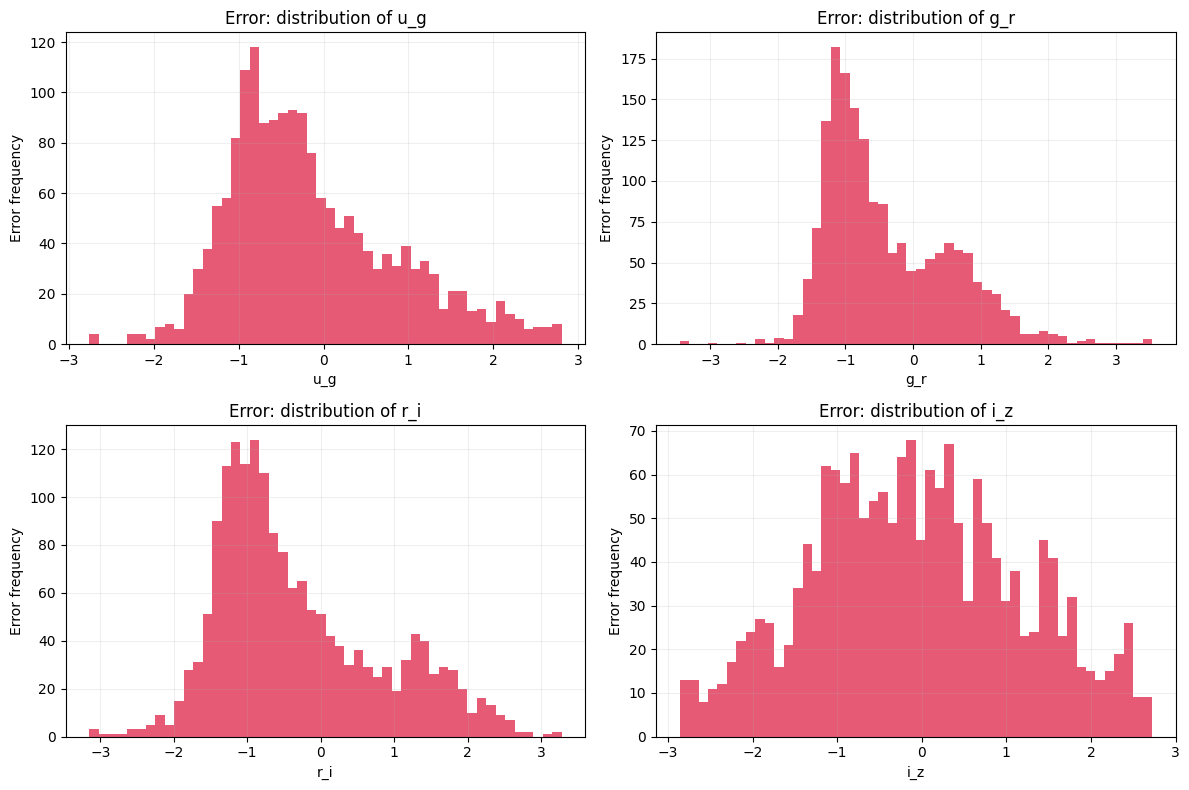

In [17]:
sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    features=["u_g", "g_r", "r_i", "i_z"]
)
#distitingui i cari errori in base alla classe reale e predetta, per capire se ci sono pattern specifici di confusione tra classi.

In [36]:
def plot_misclassified_feature_distributions_2(
    X,
    y_true,
    y_pred,
    features,
    class_names=None,
    bins=50,
    figsize=(12,5)
):

    if class_names is None:
        class_names = {
            0: "Galaxy",
            1: "Quasar",
            2: "Star"
        }

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    for feat in features:

        fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)

        for ax, true_cls in zip(axes, np.unique(y_true)):

            other_classes = [c for c in np.unique(y_true)
                             if c != true_cls]

            colors = ["tab:red", "tab:blue"]

            for pred_cls, col in zip(other_classes, colors):

                mask = (
                    (y_true == true_cls) &
                    (y_pred == pred_cls)
                )

                ax.hist(
                    X.loc[mask, feat],
                    bins=bins,
                    histtype="step",
                    linewidth=2,
                    color=col,
                    label=f"{class_names[true_cls]} → {class_names[pred_cls]}"
                )

            ax.set_title(f"True = {class_names[true_cls]}")
            ax.set_xlabel(feat)
            ax.legend()

        axes[0].set_ylabel("Count")

        fig.suptitle(f"Misclassified objects: {feat}")

        plt.tight_layout()
        plt.show()

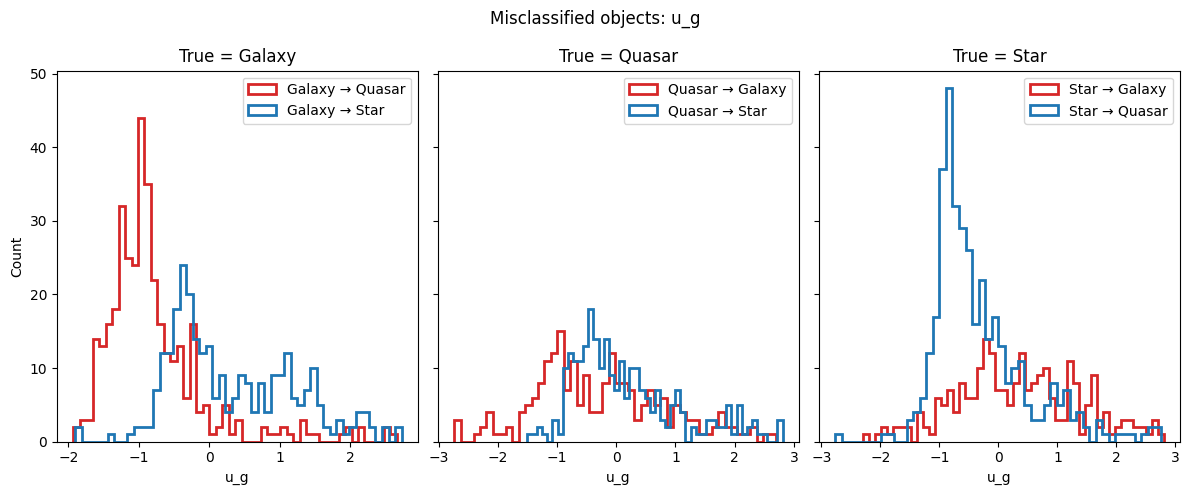

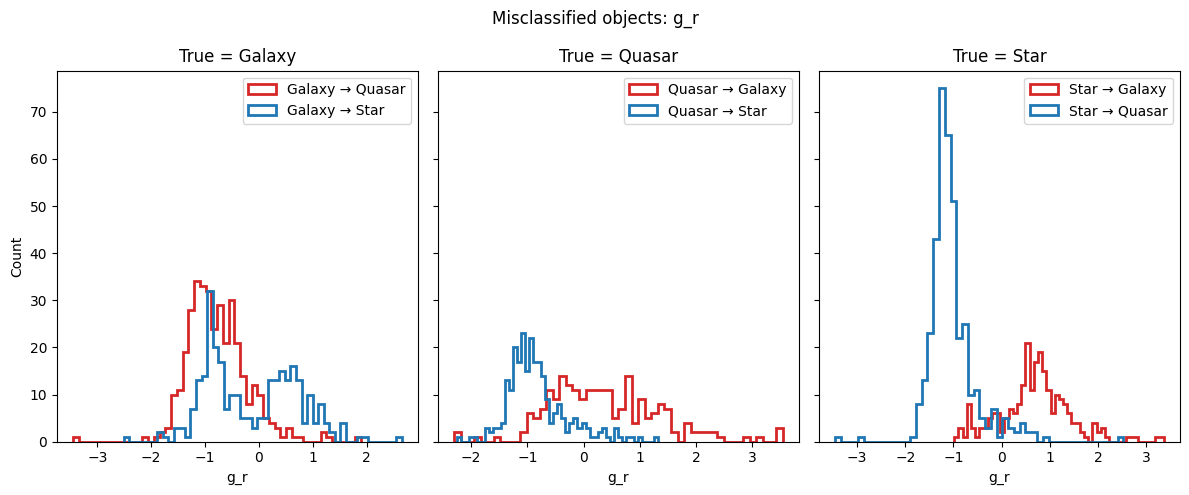

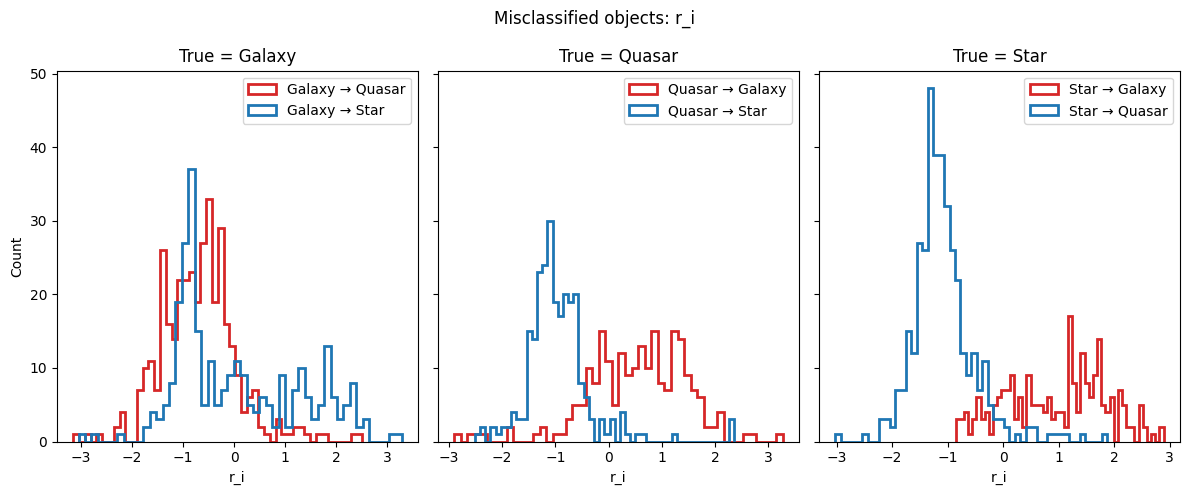

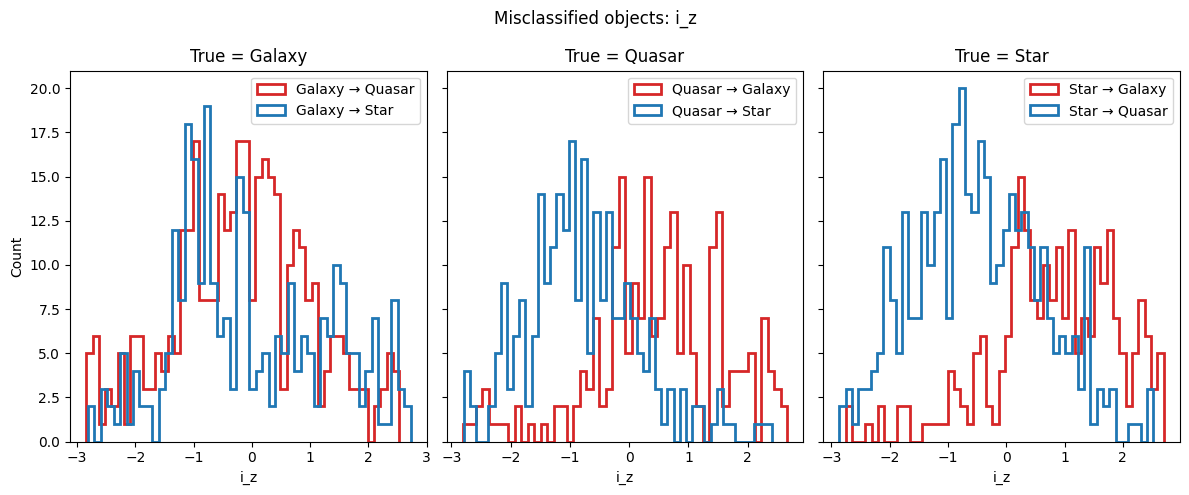

In [37]:
plot_misclassified_feature_distributions_2(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    features=["u_g", "g_r", "r_i", "i_z"]
)


In [38]:

def plot_misclassified_grid(
    X,
    y_true,
    y_pred,
    features,
    class_names=None,
    bins=40,
    figsize=None
):

    if class_names is None:
        class_names = {
            0: "Galaxy",
            1: "Star",
            2: "Quasar"
        }

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    classes = np.unique(y_true)
    n_feat = len(features)

    if figsize is None:
        figsize = (10, 2.8 * n_feat)

    fig, axes = plt.subplots(
        n_feat,
        len(classes),
        figsize=figsize,
        sharey='row'
    )

    if n_feat == 1:
        axes = axes[np.newaxis, :]

    colors = ["tab:red", "tab:blue"]

    for row, feat in enumerate(features):

        for col, true_cls in enumerate(classes):

            ax = axes[row, col]

            other_classes = [c for c in classes if c != true_cls]

            for pred_cls, color in zip(other_classes, colors):

                mask = (
                    (y_true == true_cls) &
                    (y_pred == pred_cls)
                )

                ax.hist(
                    X.loc[mask, feat],
                    bins=bins,
                    histtype="step",
                    density=True,
                    linewidth=1.8,
                    color=color,
                    label=f"{class_names[true_cls]} → {class_names[pred_cls]}"
                )

            if row == 0:
                ax.set_title(
                    f"True = {class_names[true_cls]}",
                    fontsize=11
                )

            if col == 0:
                ax.set_ylabel(feat)

            ax.grid(alpha=0.2)

            if row == n_feat - 1:
                ax.set_xlabel("Colour")

            if row == 0:
                ax.legend(fontsize=8)

    fig.suptitle(
        "Misclassified objects by true class",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

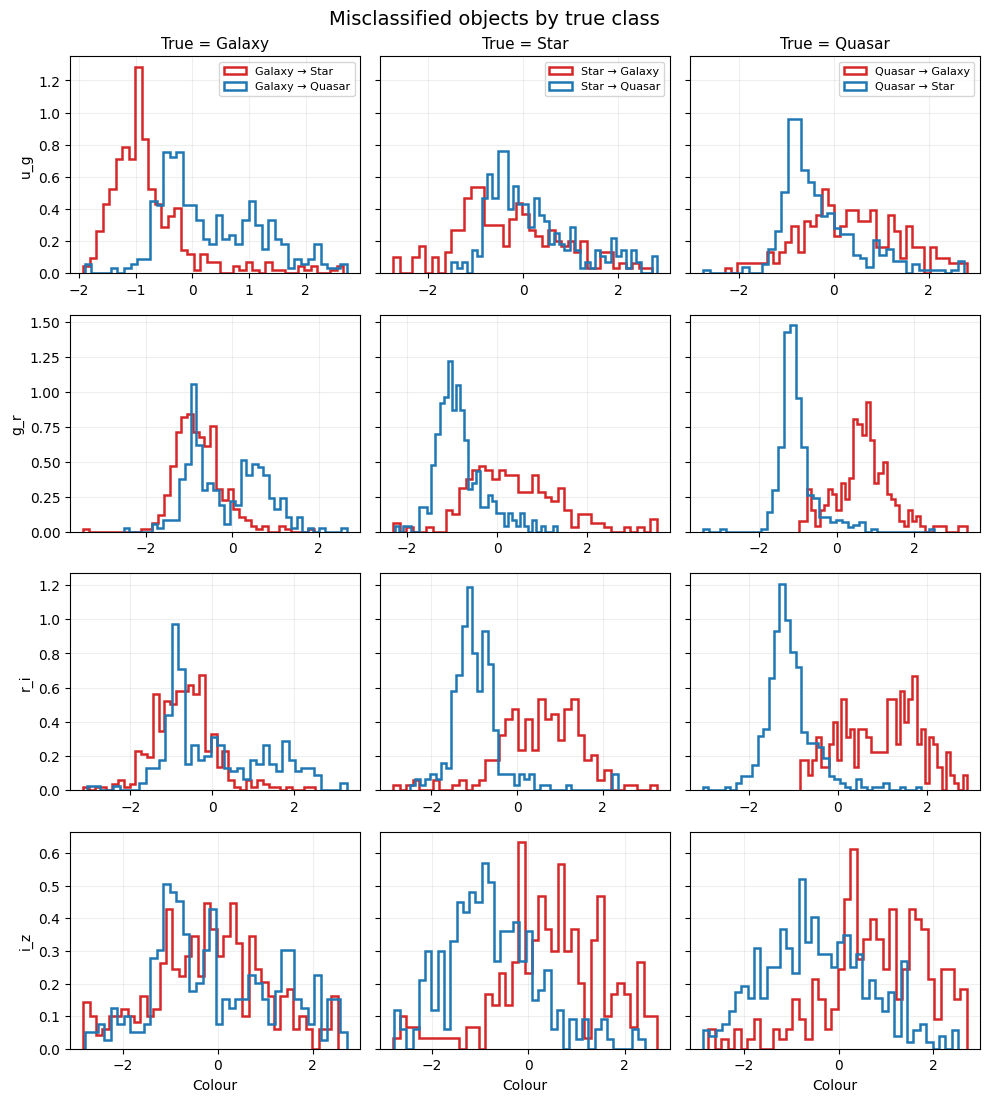

In [39]:
plot_misclassified_grid(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    features=["u_g", "g_r", "r_i", "i_z"])

In [44]:
def plot_all_misclassifications(
    X,
    y_true,
    y_pred,
    features,
    class_names=None,
    bins=40
):

    if class_names is None:
        class_names = {
            0: "Galaxy",
            1: "Star",
            2: "Quasar"
        }

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    error_pairs = [
        (0, 1),  # G -> S
        (1, 0),  # S -> G
        (0, 2),  # G -> Q
        (2, 0),  # Q -> G
        (1, 2),  # S -> Q
        (2, 1),  # Q -> S
    ]

    colors = [
        "tab:red",
        "tab:red",
        "tab:blue",
        "tab:blue",
        "tab:green",
        "tab:green"
    ]

    linestyles = [
        "-",
        "--",
        "-",
        "--",
        "-",
        "--"
    ]

    fig, axes = plt.subplots(
        2, 2,
        figsize=(10, 8)
    )

    axes = axes.ravel()

    for ax, feat in zip(axes, features):

        for (true_cls, pred_cls), c, ls in zip(
            error_pairs,
            colors,
            linestyles
        ):

            mask = (
                (y_true == true_cls) &
                (y_pred == pred_cls)
            )

            ax.hist(
                X.loc[mask, feat],
                bins=bins,
                density=True,
                histtype='step',
                linewidth=2,
                color=c,
                linestyle=ls,
                label=f"{class_names[true_cls]}→{class_names[pred_cls]}"
            )

        ax.set_xlabel(feat)
        ax.grid(alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc='upper center',
        ncol=3,
        bbox_to_anchor=(0.5, 1.02)
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

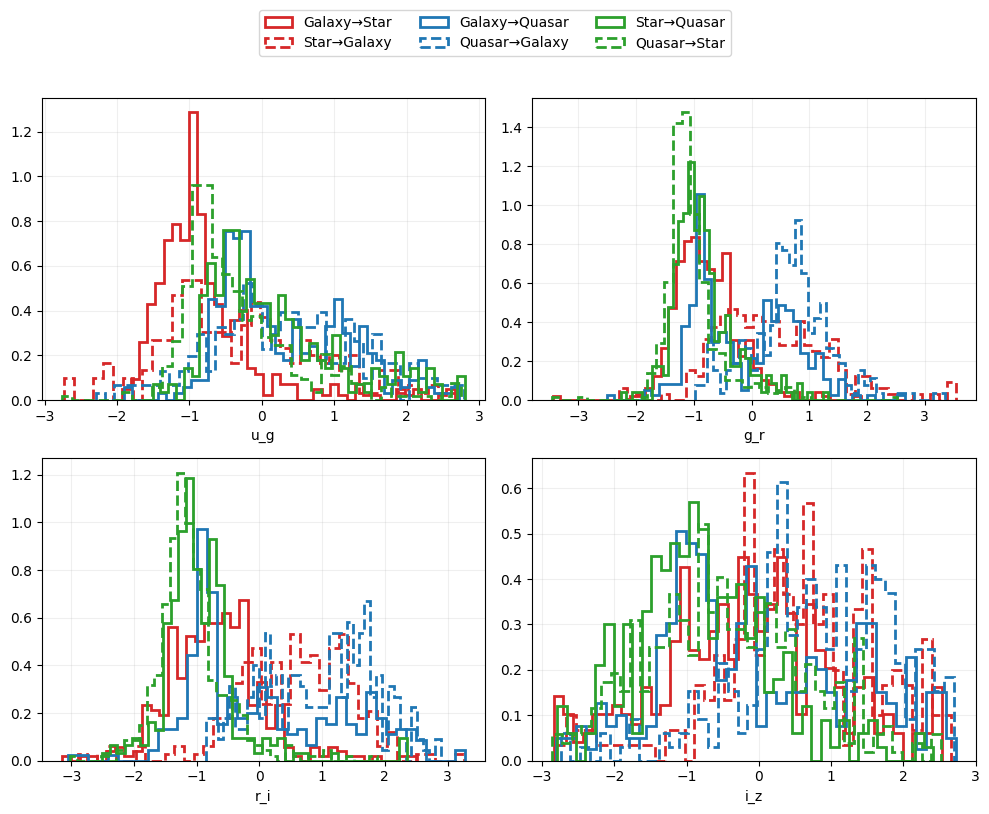

In [45]:
plot_all_misclassifications(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    features=["u_g", "g_r", "r_i", "i_z"])

In [77]:

def plot_misclassified_stacked_hist(
    X,
    y_true,
    y_pred,
    features,
    class_names=None,
    bins=40,
    figsize=(9, 9),
    density=False
):

    import pandas as pd

    if class_names is None:
        class_names = {
            0: "Galaxy",
            1: "Star",
            2: "Quasar"
        }

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # 6 tipi di errore
    error_pairs = [
        (0, 1),  # G→S
        (1, 0),  # S→G
        (0, 2),  # G→Q
        (2, 0),  # Q→G
        (1, 2),  # S→Q
        (2, 1),  # Q→S
    ]

    labels = [
        "G→S", "S→G",
        "G→Q", "Q→G",
        "S→Q", "Q→S"
    ]

    # ✔ 3 famiglie di colori (una per classe vera)
    # con tonalità diverse per distinguere forward/backward
    colors = [
        "#d62728",  # G→S (rosso)
        "#ff9896",  # S→G (rosa chiaro)

        "#1f77b4",  # G→Q (blu)
        "#aec7e8",  # Q→G (azzurro chiaro)

        "#2ca02c",  # S→Q (verde)
        "#98df8a",  # Q→S (verde chiaro)
    ]

    n_feat = len(features)

    fig, axes = plt.subplots(
        n_feat,
        1,
        figsize=figsize,
        sharex=True
    )

    if n_feat == 1:
        axes = [axes]

    for ax, feat in zip(axes, features):

        data = []

        for (true_cls, pred_cls) in error_pairs:
            mask = (y_true == true_cls) & (y_pred == pred_cls)
            data.append(X.loc[mask, feat])

        ax.hist(
            data,
            bins=bins,
            stacked=True,
            density=density,
            color=colors,
            alpha=0.9,
            label=labels
        )

        ax.set_xlabel(feat)
        ax.grid(alpha=0.25)

    #axes[-1].set_xlabel("Feature value")

    fig.suptitle(
        "Misclassified objects by true class",
    y=0.98  # abbassa leggermente il titolo
    )

    fig.legend( labels,
         loc="upper center",
         ncol=6,
         frameon=False,
         bbox_to_anchor=(0.5, 0.94)  # sotto il titolo
    )
    

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

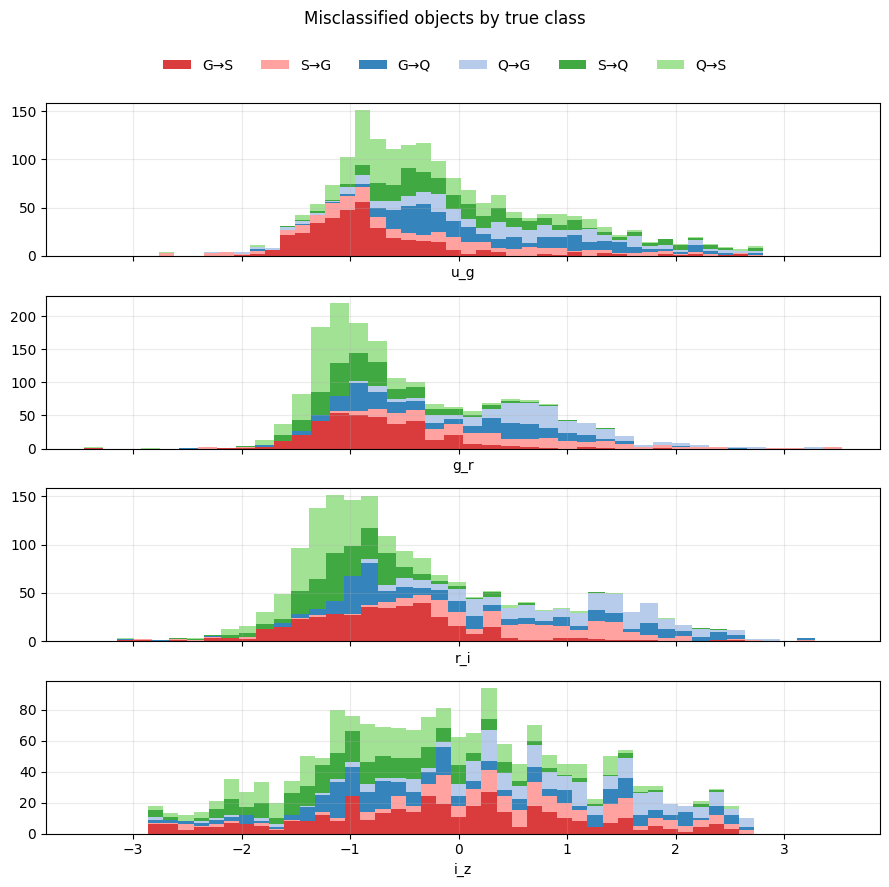

In [78]:
plot_misclassified_stacked_hist(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    features=["u_g", "g_r", "r_i", "i_z"]
)

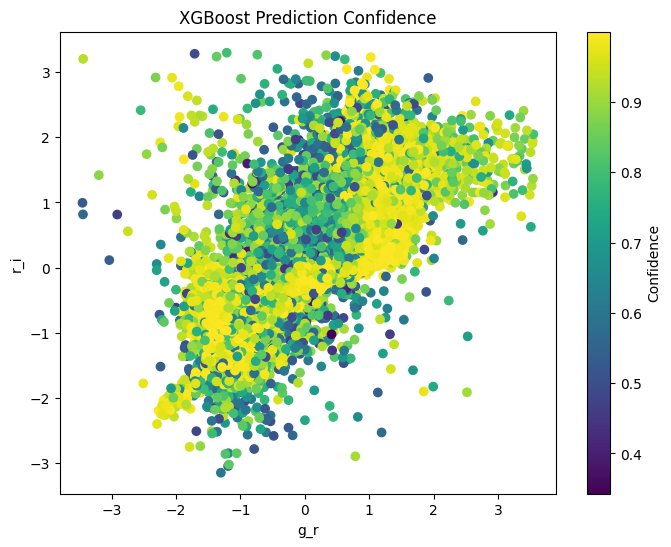

In [68]:
results_xgb = sc.predict_with_confidence(
    model=xgb_final,
    X_test=X_test,
    X_plot=X_test_df,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="XGBoost",
    threshold=0.9,
)

final_pred_xgb = results_xgb["final_predictions"]
confidence_xgb = results_xgb["confidence"]

(array([ 18.,  56., 221., 275., 213., 208., 189., 191., 182., 198.]),
 array([0.34273738, 0.40842274, 0.4741081 , 0.53979349, 0.60547888,
        0.67116421, 0.73684961, 0.80253494, 0.86822033, 0.93390572,
        0.99959105]),
 <BarContainer object of 10 artists>)

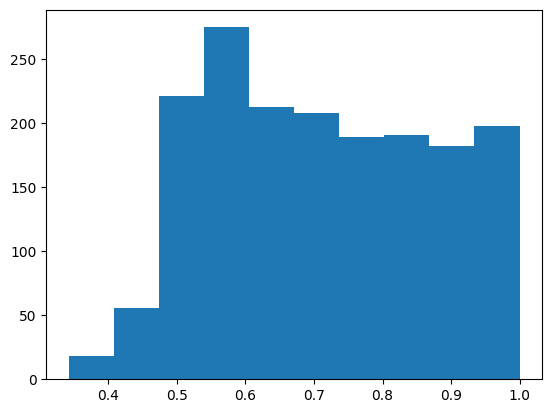

In [19]:
errors_xgb = y_test != y_test_pred_xgb

plt.hist(confidence_xgb[errors_xgb])


In [20]:
thresholds = [0.5, 0.55, 0.6, 0.65, 0.7]
from sklearn.metrics import classification_report
for threshold in thresholds:

    preds = []

    for p in probs:

        p_galaxy = p[0]
        p_quasar = p[1]
        p_star   = p[2]

        if p_quasar > threshold:

            preds.append(1)

        else:

            if p_galaxy > p_star:
                preds.append(0)

            else:
                preds.append(2)

    print(f"\nTHRESHOLD = {threshold}")

    print(
        classification_report(
            y_test,
            preds,
            target_names=['GALAXY', 'QSO', 'STAR']
        )
    )

NameError: name 'probs' is not defined

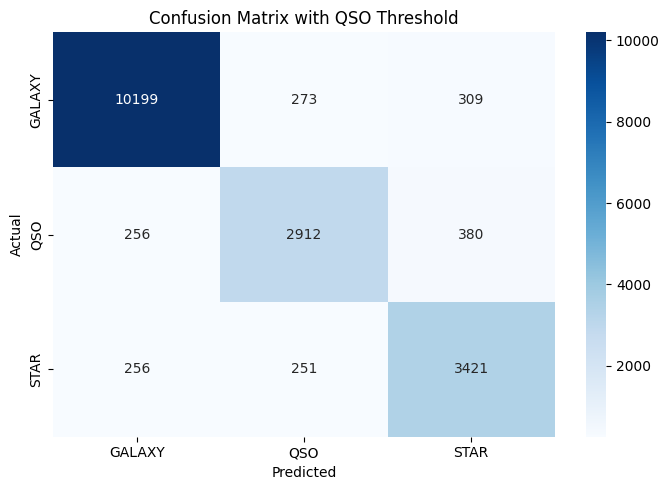

In [21]:
preds_xgb = sc.predict_with_qso_threshold(xgb_final, X_test, threshold=0.6)

cm_xgb = confusion_matrix(y_test, preds_xgb)
sc.plot_confusion_matrix(cm_xgb, class_names=['GALAXY', 'QSO', 'STAR'], title='Confusion Matrix with QSO Threshold')

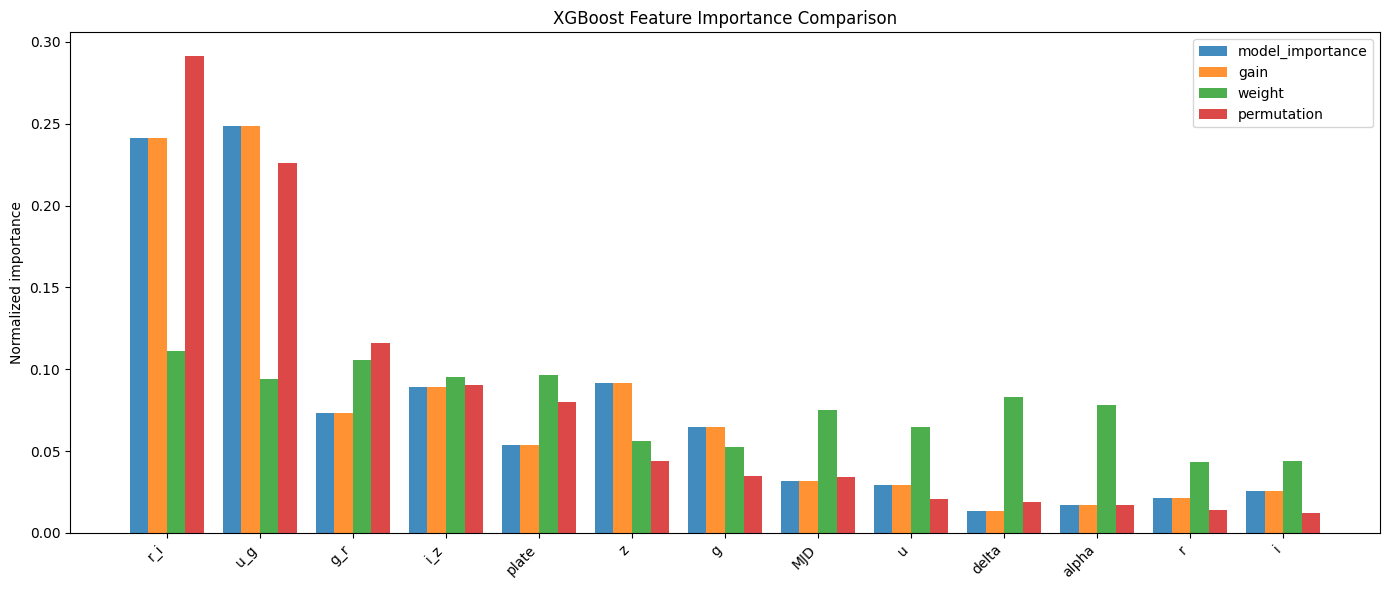

In [26]:
importance_functions = {

    "model_importance":
        lambda m: m.feature_importances_,

    "gain":
        lambda m: np.array([
            m.get_booster().get_score(
                importance_type="gain"
            ).get(f"f{i}", 0)
            for i in range(len(feature_names))
        ]),

    "weight":
        lambda m: np.array([
            m.get_booster().get_score(
                importance_type="weight"
            ).get(f"f{i}", 0)
            for i in range(len(feature_names))
        ])
}

df_imp = sc.plot_feature_importance(
    xgb_final,
    feature_names,
    prefix_name="XGBoost",

    importance_functions=importance_functions,

    use_permutation=True,
    X_test=X_test,
    y_test=y_test,

    top_k=15,
    sort_by="permutation"
)

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
  File "/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/xgboost

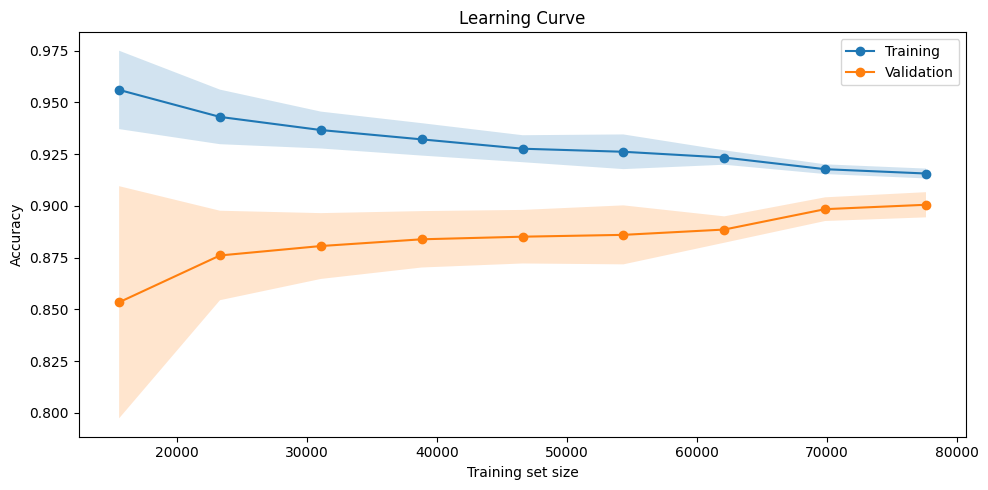

In [31]:
xgb_lc = XGBClassifier(**xgb_final.get_params())

# removed early stopping
xgb_lc.set_params(early_stopping_rounds=None)

sc.plot_learning_curve(
    xgb_lc,
    X_train,
    y_train
)

## LightGBM

In [18]:
import os
os.environ["LIGHTGBM_VERBOSITY"] = "-1"
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_jobs=3,verbose=-1)
params = {"n_estimators": [300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "num_leaves": [15, 31], 
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10], 
  } 
   
best_model_lgbm, best_params_lgbm, best_score_lgbm = sc.tune_model(
    lgbm,
    params,
    X_train,
    y_train,verbose=False
)

print("Best Hyperparameters:", best_params_lgbm)

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'num_leaves': 31, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [19]:
best_params_lgbm.pop("n_estimators", None)
best_params_lgbm.pop("max_depth", None)
lgbm_final = LGBMClassifier(**best_params_lgbm,n_estimators=1000,max_depth=3,verbose=-1 )

import lightgbm as lgb
lgbm_final.fit(X_train, y_train,eval_set=[(X_val, y_val)],  eval_metric='multi_logloss',  callbacks=[lgb.early_stopping(50)])

train_metrics_lgbm, val_metrics_lgbm = sc.evaluate_single_model(
    lgbm_final,
    X_train, y_train,
    X_val, y_val,
    model_name="LightGBM Tuned"
)

y_test_pred_lgbm = lgbm_final.predict(X_test)
lgbm_metrics = sc.evaluate_test_set(y_test, y_test_pred_lgbm, "LightGBM")
sc.print_metrics(lgbm_metrics)

X_test_df = pd.DataFrame(X_test, columns=feature_names)


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[990]	valid_0's multi_logloss: 0.290654


/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Training] Acc=91.6759% P=0.9168 R=0.9168 F1=0.9167
Confusion Matrix:
[[30627   930   787]
 [ 1576 29264  1504]
 [ 1174  2106 29064]]

[Validation] Acc=90.3215% P=0.8728 R=0.8802 F1=0.8759
Confusion Matrix:
[[10144   356   281]
 [  219  3081   248]
 [  264   399  3265]]



/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM:
  Accuracy  : 90.34%
  Precision: 0.8727
  Recall   : 0.8816
  F1       : 0.8767
  Confusion Matrix:
[[10122   367   292]
 [  226  3067   255]
 [  244   379  3305]]


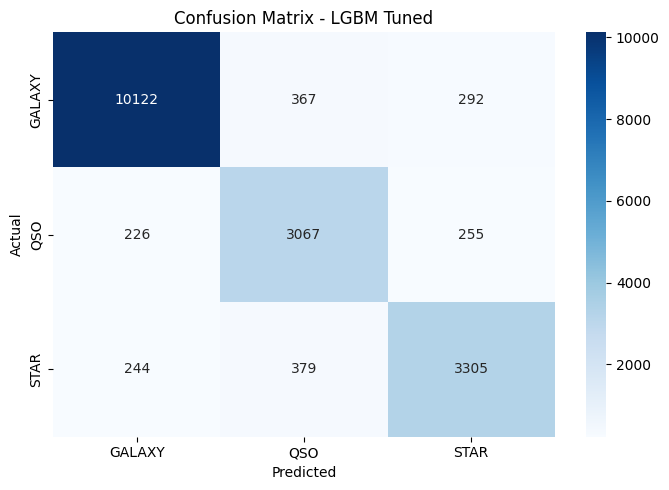

In [20]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(lgbm_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - LGBM Tuned')


SHAP summary for class: GALAXY


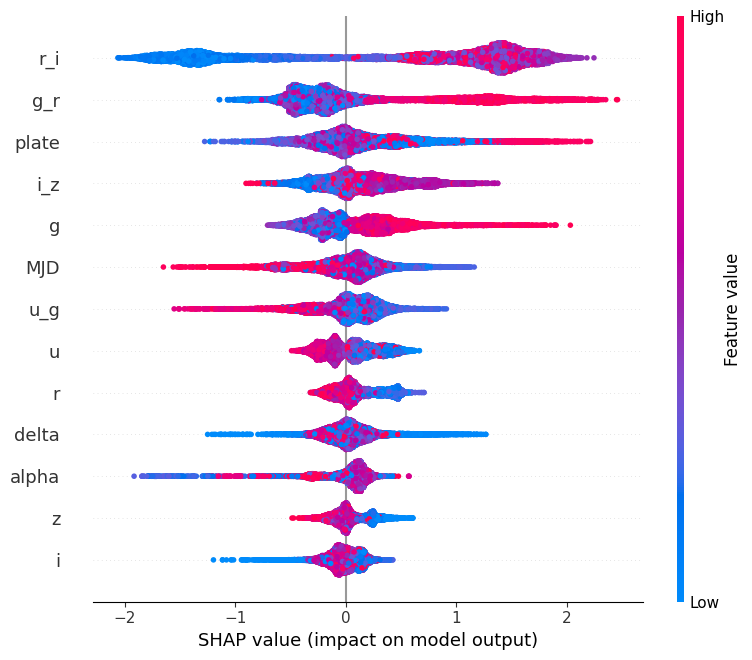


SHAP summary for class: QSO


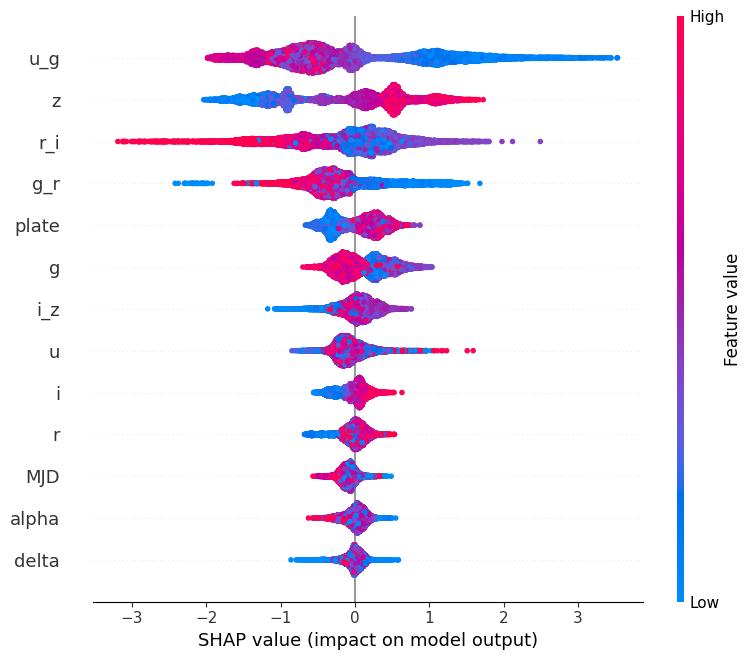


SHAP summary for class: STAR


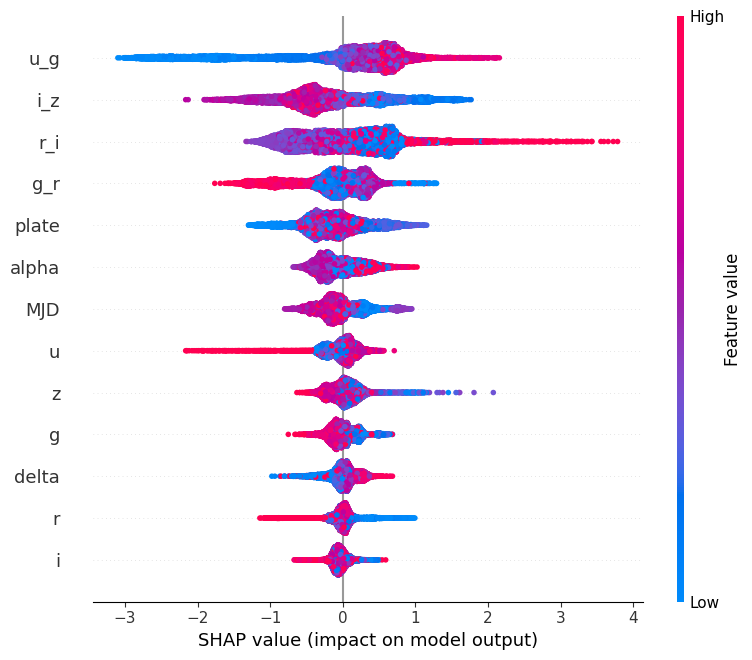

In [21]:
shap_values_lgbm = sc.shap_summary_tree_model(
    model=lgbm_final,
    X=X_test,
    feature_names=feature_names,
    class_names=label_encoder.classes_
)

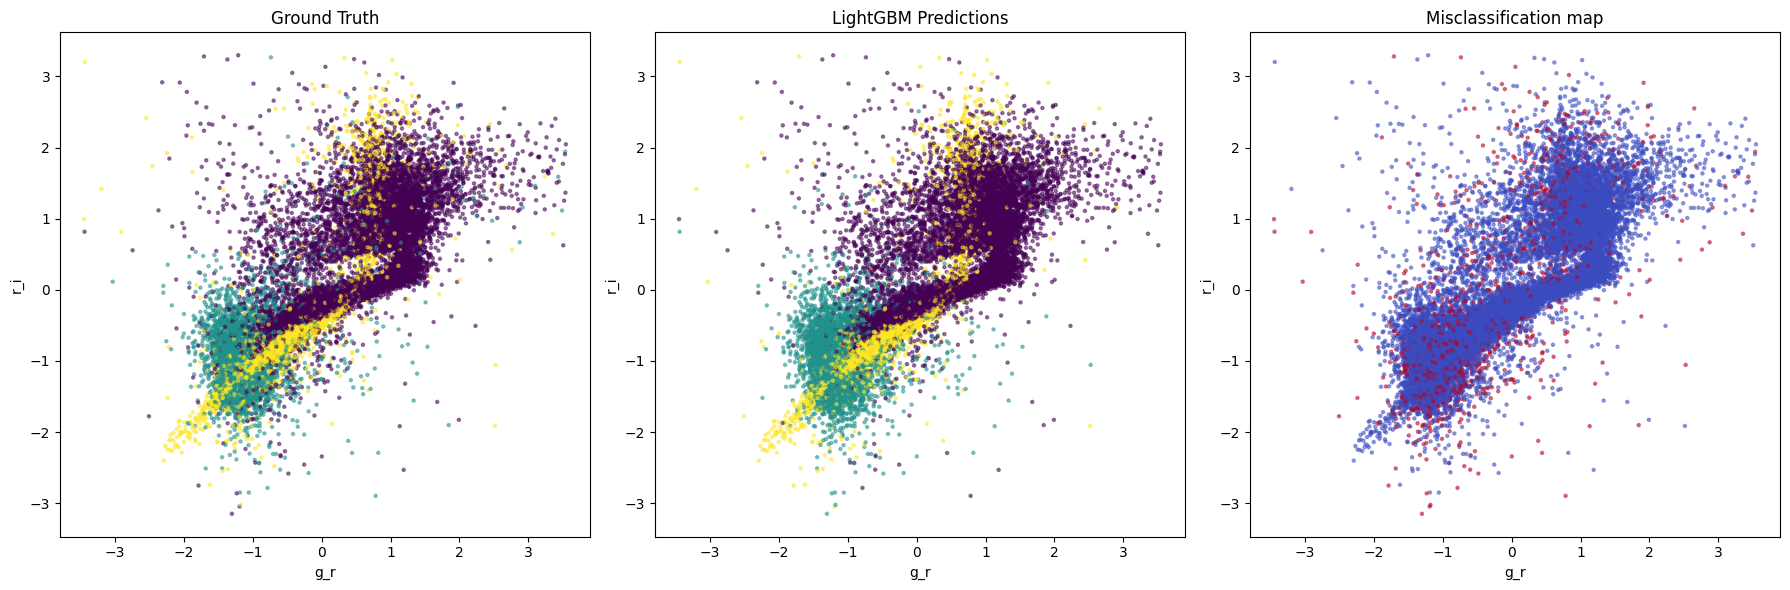

In [22]:
sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="LightGBM"
)

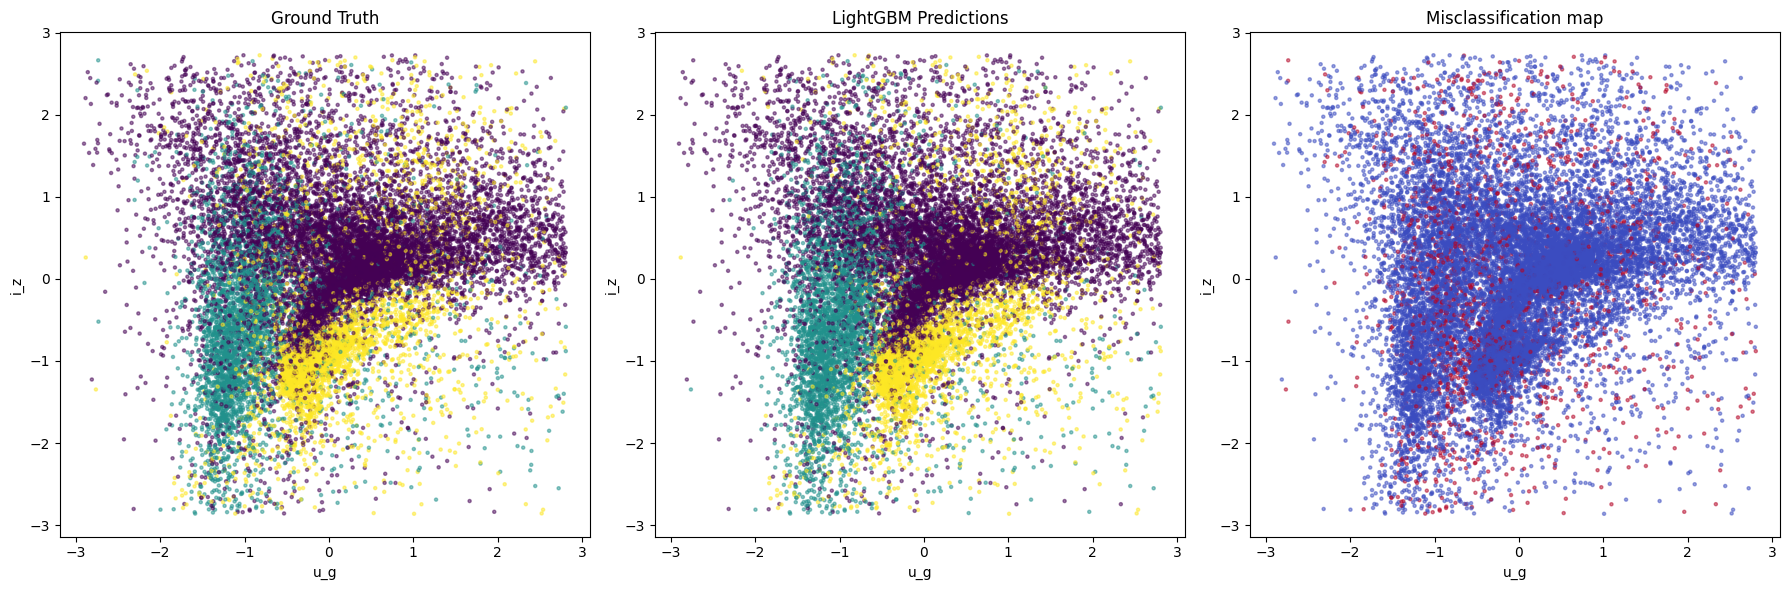

In [23]:
sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    feature_x="u_g",
    feature_y="i_z",
    title_prefix="LightGBM"
)

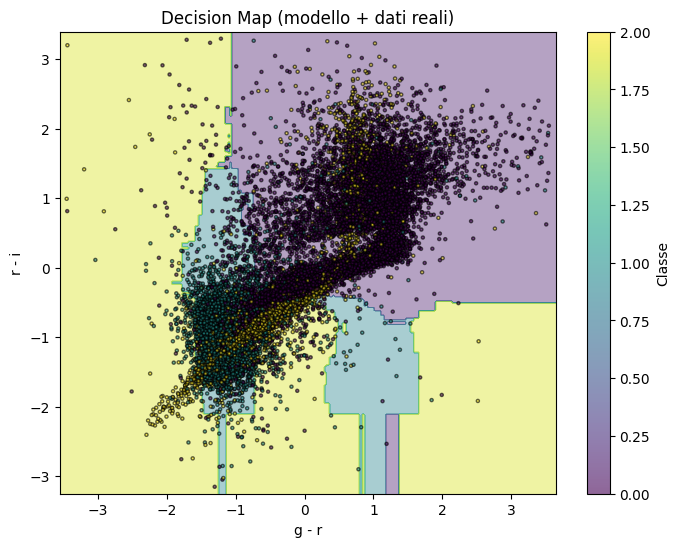

In [24]:
X = X_test_df.copy()   
y = y_test        

# 2. SCELTA PIANO 2D
x_feat = "g_r"
y_feat = "r_i"

x_min, x_max = X[x_feat].min() - 0.1, X[x_feat].max() + 0.1
y_min, y_max = X[y_feat].min() - 0.1, X[y_feat].max() + 0.1

# 3. GRIGLIA
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]


# 4. INPUT MODELLO COMPLETO
# ordine delle feature usate nel modello
feature_names = X.columns

X_dummy = pd.DataFrame(
    np.zeros((grid.shape[0], len(feature_names))),
    columns=feature_names
)

# inserisci le 2 feature del piano
X_dummy[x_feat] = grid[:, 0]
X_dummy[y_feat] = grid[:, 1]

# riempi le altre con la media (approssimazione standard)
for col in feature_names:
    if col not in [x_feat, y_feat]:
        X_dummy[col] = X[col].mean()


# 5. PREDIZIONE
Z = lgbm_final.predict(X_dummy)
Z = Z.reshape(xx.shape)

# 6. PLOT
plt.figure(figsize=(8,6))

# decision boundary del modello
plt.contourf(xx, yy, Z, alpha=0.4, cmap="viridis")

# punti reali
plt.scatter( X[x_feat], X[y_feat],  c=y, s=5, cmap="viridis", edgecolor="k", alpha=0.6)

plt.xlabel("g - r")
plt.ylabel("r - i")
plt.title("Decision Map (modello + dati reali)")
plt.colorbar(label="Classe")
plt.show()

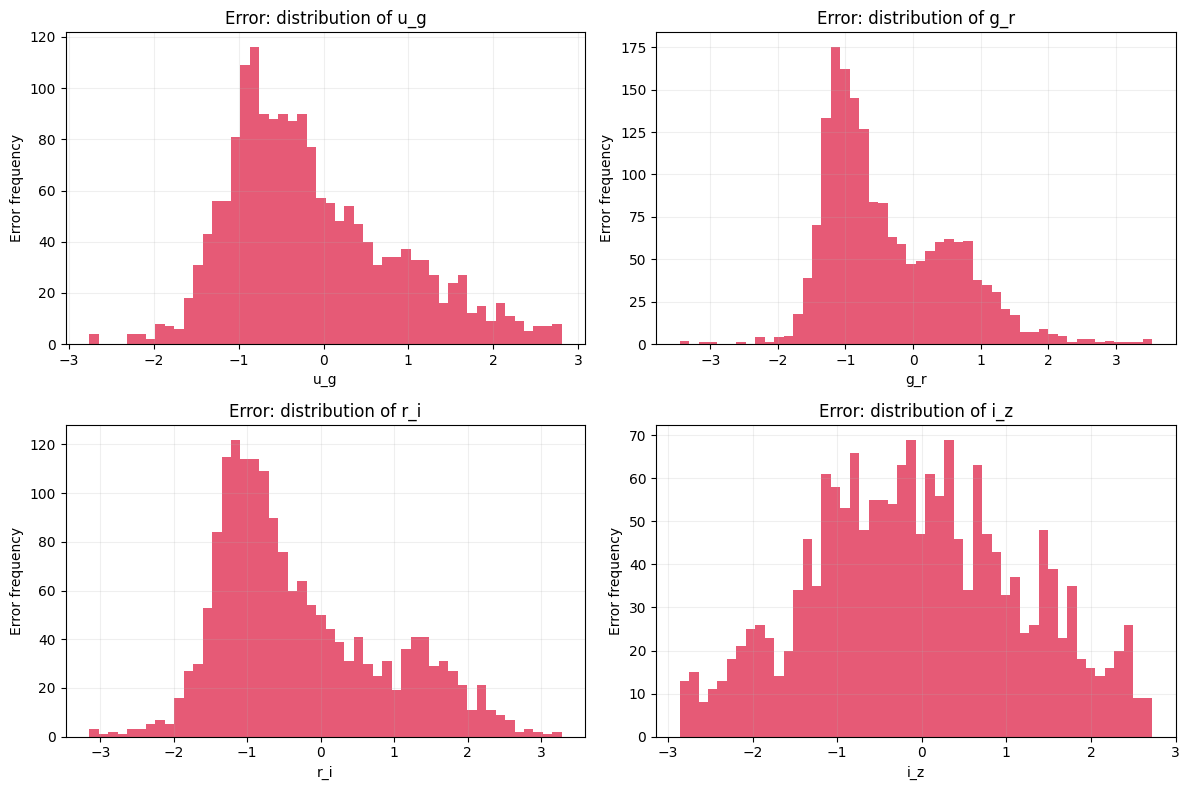

In [25]:
sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    features=["u_g", "g_r", "r_i", "i_z"]
)

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


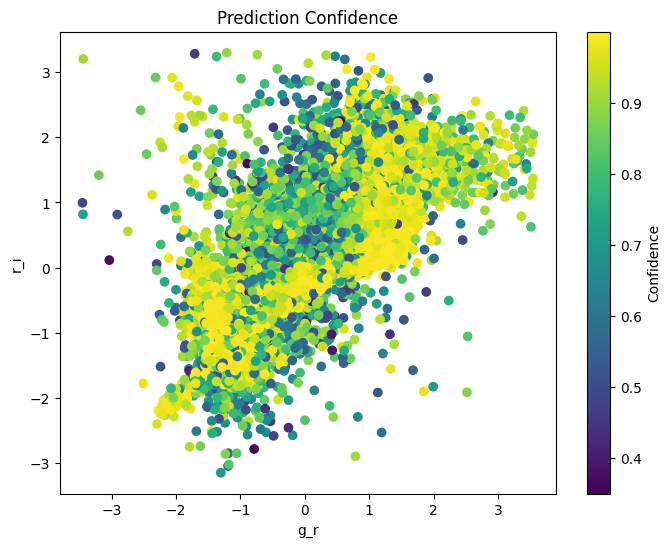

In [ ]:
results_lgbm = sc.predict_with_confidence(
    model=lgbm_final,
    X_test=X_test,
    X_plot=X_test_df,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="LightGBM",
    threshold=0.9,
)

final_pred_lgbm = results_lgbm["final_predictions"]
confidence_lgbm = results_lgbm["confidence"]

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


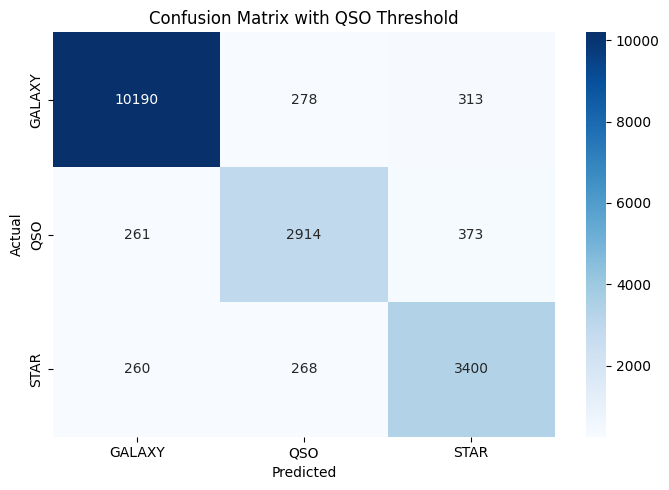

In [27]:
preds_lgbm = sc.predict_with_qso_threshold(lgbm_final, X_test, threshold=0.6)

cm_lgbm = confusion_matrix(y_test, preds_lgbm)
sc.plot_confusion_matrix(cm_lgbm, class_names=['GALAXY', 'QSO', 'STAR'], title='Confusion Matrix with QSO Threshold')

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

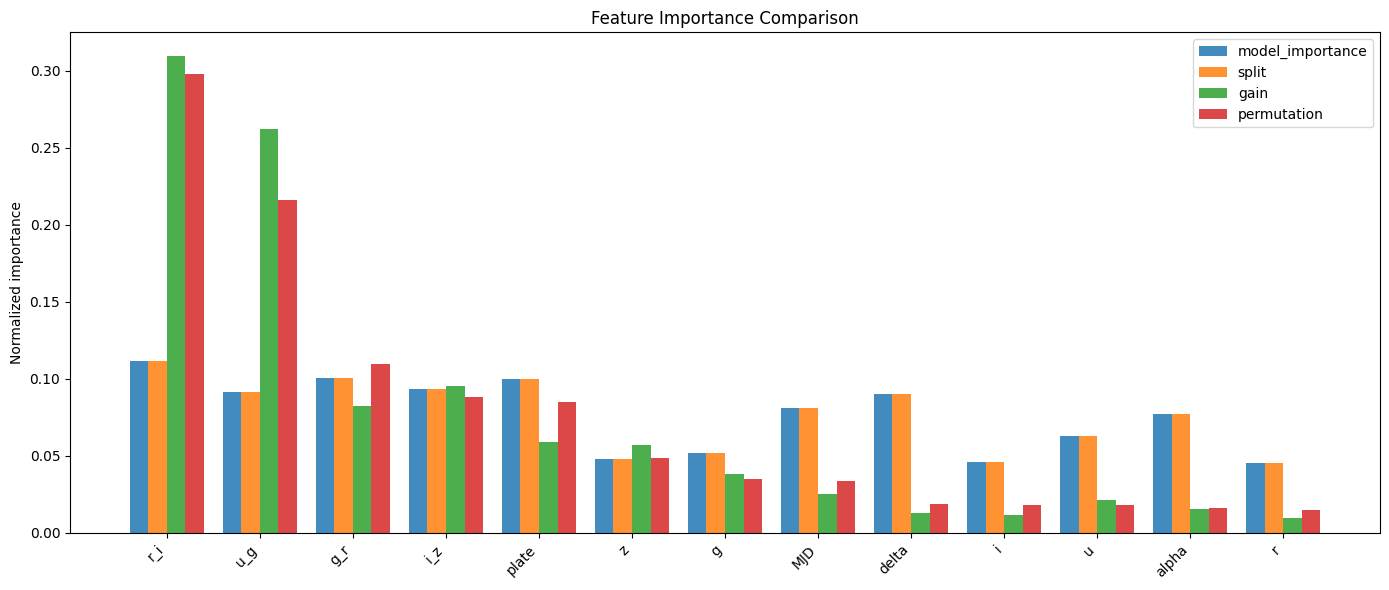

In [ ]:
importance_functions = {

    # sklearn-style importance
    "model_importance":
        lambda m: m.feature_importances_,

    # numero split
    "split":
        lambda m: m.booster_.feature_importance(
            importance_type="split"
        ),

    # gain totale
    "gain":
        lambda m: m.booster_.feature_importance(
            importance_type="gain"
        )
}

df_imp = sc.plot_feature_importance(
    lgbm_final,
    feature_names,
    prefix_name="LightGBM",

    importance_functions=importance_functions,

    use_permutation=True,
    X_test=X_test,
    y_test=y_test,

    top_k=15,
    sort_by="permutation"
)

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

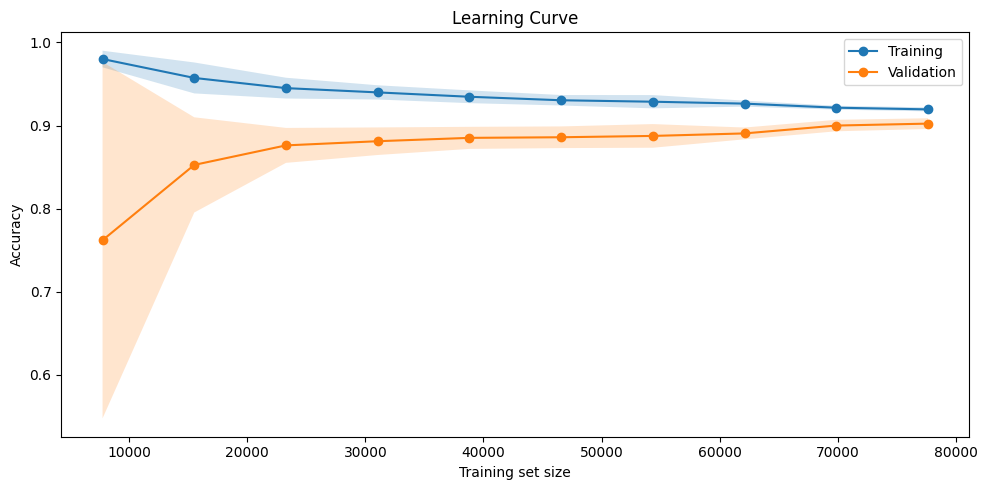

In [30]:
lgbm_lc = LGBMClassifier(**lgbm_final.get_params())

# removed early stopping
lgbm_lc.set_params(early_stopping_rounds=None)

sc.plot_learning_curve(
    lgbm_lc,
    X_train,
    y_train
)

/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/sara/anaconda3/envs/comp_phys/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid featur

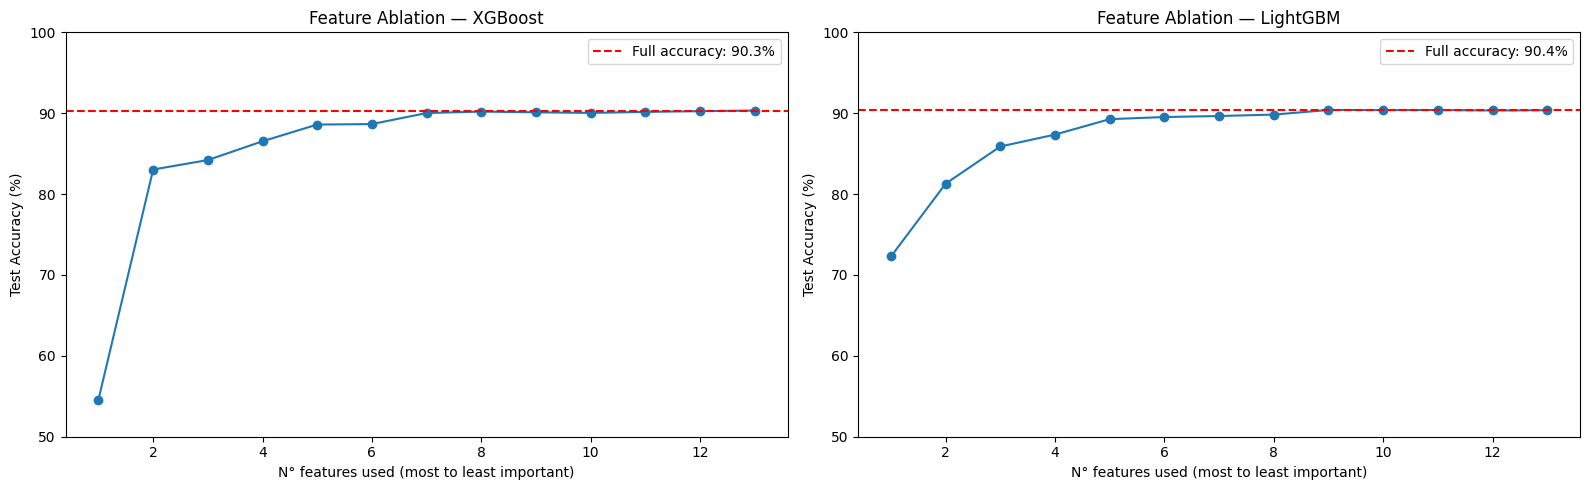

In [29]:
#feature ablation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

xgb_ablation = XGBClassifier(
    n_estimators=1000,   
    max_depth=xgb_final.max_depth,
    learning_rate=xgb_final.learning_rate,
    subsample=xgb_final.subsample,
    colsample_bytree=xgb_final.colsample_bytree,
    random_state=42
)
xgb_ablation.fit(X_train, y_train)
sc.plot_feature_ablation(xgb_ablation, X_train, X_test, y_train, y_test,
                         feature_names, 
                         title='Feature Ablation — XGBoost',
                         ax=axes[0])


lgbm_ablation = LGBMClassifier(
    n_estimators=1000,
    max_depth=lgbm_final.max_depth,
    learning_rate=lgbm_final.learning_rate,
    subsample=lgbm_final.subsample,
    colsample_bytree=lgbm_final.colsample_bytree,
    reg_alpha=lgbm_final.reg_alpha,
    reg_lambda=lgbm_final.reg_lambda,
)
lgbm_ablation.fit(X_train, y_train)
sc.plot_feature_ablation(lgbm_ablation, X_train, X_test, y_train, y_test,
                         feature_names,
                         title='Feature Ablation — LightGBM',
                         ax=axes[1])

axes[0].set_ylim(50, 100)
axes[1].set_ylim(50, 100)
plt.tight_layout()
plt.show()

## Only physical features with new colors

In [35]:
star["u_r"] = star["u"] - star["r"]
star["g_i"] = star["g"] - star["i"]
star["r_z"] = star["r"] - star["z"]

star_new = star.drop(columns=['plate','MJD','alpha','delta'])
star_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   u            100000 non-null  float64
 2   g            100000 non-null  float64
 3   r            100000 non-null  float64
 4   i            100000 non-null  float64
 5   z            100000 non-null  float64
 6   run_ID       100000 non-null  int64  
 7   rerun_ID     100000 non-null  int64  
 8   cam_col      100000 non-null  int64  
 9   field_ID     100000 non-null  int64  
 10  spec_obj_ID  100000 non-null  float64
 11  class        100000 non-null  str    
 12  redshift     100000 non-null  float64
 13  fiber_ID     100000 non-null  int64  
 14  u_g          100000 non-null  float64
 15  g_r          100000 non-null  float64
 16  u_r          100000 non-null  float64
 17  g_i          100000 non-null  float64
 18  r_z          100000 non-null  float6

In [36]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train_new, X_val_new, X_test_new, y_train_new, y_val_new, y_test_new, label_encoder_new, scaler_new, feature_names_new = sc.prepare_splits(
    star_new, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train_new.shape}")
print(f"X_val shape: {X_val_new.shape}")
print(f"X_test shape: {X_test_new.shape}")


# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train_new, y_train_new, 
    X_val_new, y_val_new, 
    X_test_new, y_test_new, 
    batch_size=64
)

print("DataLoaders created.")

Outliers removed: 5,111 rows  (94,889 remain)
X_train shape: (100692, 10)
X_val shape: (18978, 10)
X_test shape: (18978, 10)
DataLoaders created.


In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

params = {"n_estimators": [300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10],
}

best_model_xgb_new, best_params_xgb_new, best_score_xgb_new = sc.tune_model(
    xgb,
    params,
    X_train_new,
    y_train_new,
)

print("Best Hyperparameters:", best_params_xgb_new)

KeyboardInterrupt: 

In [ ]:
best_params_xgb_new.pop("n_estimators", None)

xgb_final_new = XGBClassifier(**best_params_xgb_new,n_estimators=800, objective="multi:softprob",
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=42)
xgb_final_new.fit(X_train_new, y_train_new ,eval_set=[(X_val_new, y_val_new)],verbose=False)

train_metrics_xgb_new, val_metrics_xgb_new = sc.evaluate_single_model(
    xgb_final_new,
    X_train_new, y_train_new,
    X_val_new, y_val_new,
    model_name="XGBoost Tuned"
)

y_test_pred_xgb_new = xgb_final_new.predict(X_test_new)
xgb_metrics_new = sc.evaluate_test_set(y_test_new, y_test_pred_xgb_new, "XGBoost")
sc.print_metrics(xgb_metrics_new )
X_test_df_new = pd.DataFrame(X_test_new, columns=feature_names_new)


[Training] Acc=91.1780% P=0.9121 R=0.9118 F1=0.9117
Confusion Matrix:
[[31434  1035  1095]
 [ 1719 30470  1375]
 [ 1868  1791 29905]]

[Validation] Acc=87.5593% P=0.8411 R=0.8502 F1=0.8454
Confusion Matrix:
[[10259   449   480]
 [  316  3101   312]
 [  399   405  3257]]


XGBoost:
  Accuracy  : 87.94%
  Precision: 0.8458
  Recall   : 0.8569
  F1       : 0.8511
  Confusion Matrix:
[[10249   440   499]
 [  279  3123   326]
 [  394   350  3318]]


In [ ]:
# Feature Importance (using permutation importance on the XGBoost Classifier)
imp_xgb_new = sc.compute_permutation_importance(xgb_final_new, X_test_new, y_test_new, feature_names=feature_names_new)
sc.plot_permutation_importance(imp_xgb_new, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp_xgb_new.items():
    print(f"{feat}: {val:.4f}")


In [ ]:
shap_values_xgb_new = sc.shap_summary_tree_model(
    model=xgb_final_new,
    X=X_test_new,
    feature_names=feature_names_new,
    class_names=label_encoder_new.classes_
)

In [ ]:
sc.plot_misclassified_feature_distributions(
    X_test_df_new,
    y_test_new,
    y_test_pred_xgb_new,
    features=["u_g", "g_r", "r_i", "i_z",]
)

In [ ]:
import os
os.environ["LIGHTGBM_VERBOSITY"] = "-1"
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_jobs=3,verbose=-1)
params = {"n_estimators": [30, 50],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "num_leaves": [15, 31], 
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10], 
  } 
   
best_model_lgbm_new, best_params_lgbm_new, best_score_lgbm_new = sc.tune_model(
    lgbm,
    params,
    X_train_new,
    y_train_new,verbose=False
)

print("Best Hyperparameters:", best_params_lgbm_new)

In [ ]:
best_params_lgbm_new.pop("n_estimators", None)
lgbm_final_new = LGBMClassifier(**best_params_lgbm_new,n_estimators=1000,verbose=-1 )

import lightgbm as lgb
lgbm_final_new.fit(X_train_new, y_train_new,eval_set=[(X_val_new, y_val_new)],  eval_metric='multi_logloss',  callbacks=[lgb.early_stopping(50)])

train_metrics_lgbm, val_metrics_lgbm = sc.evaluate_single_model(
    lgbm_final_new,
    X_train_new, y_train_new,
    X_val_new, y_val_new,
    model_name="LightGBM Tuned"
)

y_test_pred_lgbm_new = lgbm_final_new.predict(X_test_new)
lgbm_metrics_new = sc.evaluate_test_set(y_test_new, y_test_pred_lgbm_new, "LightGBM")
sc.print_metrics(lgbm_metrics_new)

X_test_df_new = pd.DataFrame(X_test_new, columns=feature_names_new)


In [ ]:
# Feature Importance (using permutation importance on the LGBM Classifier)
imp_lgbm_new = sc.compute_permutation_importance(lgbm_final_new, X_test_new, y_test_new, feature_names=feature_names_new)
sc.plot_permutation_importance(imp_lgbm_new, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp_lgbm_new.items():
    print(f"{feat}: {val:.4f}")


In [ ]:
sc.plot_misclassified_feature_distributions(
    X_test_df_new,
    y_test_new,
    y_test_pred_lgbm_new,
    features=["u_g", "g_r", "r_i", "i_z"]
)

## Only color features

In [ ]:
star_c = star_new.drop(columns=['u','g','r','i','z'])

# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c, label_encoder_c, scaler_c, feature_names_c = sc.prepare_splits(
    star_c, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train_c.shape}")
print(f"X_val shape: {X_val_c.shape}")
print(f"X_test shape: {X_test_c.shape}")


# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train_c, y_train_c, 
    X_val_c, y_val_c, 
    X_test_c, y_test_c, 
    batch_size=64
)

print("DataLoaders created.")

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

params = {"n_estimators": [30, 50],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10],
}

best_model_xgb_c, best_params_xgb_c, best_score_xgb_c = sc.tune_model(
    xgb,
    params,
    X_train_c,
    y_train_c,
)

print("Best Hyperparameters:", best_params_xgb_c)

In [ ]:
best_params_xgb_c.pop("n_estimators", None)

xgb_final_c = XGBClassifier(**best_params_xgb_c,n_estimators=500, objective="multi:softprob",
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=42)
xgb_final_c.fit(X_train_c, y_train_c ,eval_set=[(X_val_c, y_val_c)],verbose=False)

train_metrics_xgb_c, val_metrics_xgb_c = sc.evaluate_single_model(
    xgb_final_c,
    X_train_c, y_train_c,
    X_val_c, y_val_c,
    model_name="XGBoost Tuned"
)

y_test_pred_xgb_c = xgb_final_c.predict(X_test_c)
xgb_metrics_c = sc.evaluate_test_set(y_test_c, y_test_pred_xgb_c, "XGBoost")
sc.print_metrics(xgb_metrics_c )
X_test_df_c = pd.DataFrame(X_test_c, columns=feature_names_c)


In [ ]:
# Feature Importance (using permutation importance on the XGBoost Classifier)
imp_xgb_c = sc.compute_permutation_importance(xgb_final_c, X_test_c, y_test_c, feature_names=feature_names_c)
sc.plot_permutation_importance(imp_xgb_c, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp_xgb_c.items():
    print(f"{feat}: {val:.4f}")
